In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import shap

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

PROCESSED = Path("../data/processed")
print("Libraries loaded")

Libraries loaded


In [2]:
df = pd.read_csv(PROCESSED / "er_visits_clean.csv",
                 parse_dates=["visit_datetime"])

print(f"Shape: {df.shape}")
print(f"\nTarget variable stats:")
print(df["total_wait_time_min"].describe().round(1))
print(f"\nNull values in target: {df['total_wait_time_min'].isna().sum()}")

Shape: (5000, 25)

Target variable stats:
count    5000.0
mean       81.9
std        68.1
min         4.0
25%        27.0
50%        60.0
75%       122.0
max       442.0
Name: total_wait_time_min, dtype: float64

Null values in target: 0


In [3]:
# ─────────────────────────────────────────────────────────────
# Feature Engineering
# ─────────────────────────────────────────────────────────────
# In this step, I prepare the dataset for machine learning.
# The goal is to predict the total ER wait time in minutes.
#
# Target:
#   total_wait_time_min
#
# Important note:
# I only use features that would be available when the patient arrives or shortly after triage. 
# I avoid using columns that are already part of the wait time calculation, because that would cause data leakage.

features = [
    # Patient / arrival information
    "urgency_level",       # triage urgency level assigned to the patient
    "time_of_day",         # arrival time bucket, such as Morning or Evening
    "day_of_week",         # day the patient arrived
    "season",              # season of the visit

    # Hospital capacity and staffing information
    "facility_beds",       # number of available hospital beds
    "nurse_patient_ratio", # staffing level compared to patient volume
    "specialist_count",    # number of specialists available

    # Time-based numeric features
    "visit_hour",          # hour extracted from visit_datetime
    "visit_month",         # month extracted from visit_datetime
]

target = "total_wait_time_min"



df_model = df[features + [target]].dropna().copy()


cat_cols = ["urgency_level", "time_of_day", "day_of_week", "season"]

# I store the encoders so I can reuse them later if I need to transform new data or understand what each encoded number means.
encoders = {}

for col in cat_cols:
    le = LabelEncoder()

    # Convert the column to string first to avoid issues if there are mixed data types, then transform each category into a number.
    df_model[col] = le.fit_transform(df_model[col].astype(str))

    # Save the encoder for this column.
    encoders[col] = le

    # Print the mapping so I can clearly see how each category was encoded.
    print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")



print(f"\nFinal shape : {df_model.shape}")
print(f"Null values : {df_model.isnull().sum().sum()}")

urgency_level: {'Critical': 0, 'High': 1, 'Low': 2, 'Medium': 3}
time_of_day: {'Afternoon': 0, 'Early Morning': 1, 'Evening': 2, 'Late Morning': 3, 'Night': 4}
day_of_week: {'Friday': 0, 'Monday': 1, 'Saturday': 2, 'Sunday': 3, 'Thursday': 4, 'Tuesday': 5, 'Wednesday': 6}
season: {'Fall': 0, 'Spring': 1, 'Summer': 2, 'Winter': 3}

Final shape : (5000, 10)
Null values : 0


In [4]:
# ─────────────────────────────────────────────────────────────
# Train / Test Split
# ─────────────────────────────────────────────────────────────


X = df_model.drop(columns=[target])
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train : {len(X_train):,} rows")
print(f"Test  : {len(X_test):,} rows")
print(f"\nTarget distribution:")
print(f"  Train mean : {y_train.mean():.1f} min")
print(f"  Test mean  : {y_test.mean():.1f} min")

Train : 4,000 rows
Test  : 1,000 rows

Target distribution:
  Train mean : 81.9 min
  Test mean  : 82.1 min


In [5]:
# ─────────────────────────────────────────────────────────────
# Model 1: Linear Regression Baseline
# ─────────────────────────────────────────────────────────────
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)

# ─────────────────────────────────────────────────────────────
# Model 2: XGBoost Regressor
# ─────────────────────────────────────────────────────────────
xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    verbosity=0
)

xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

# ─────────────────────────────────────────────────────────────
# Evaluation
# ─────────────────────────────────────────────────────────────
# MAE  : average minutes your prediction is off by
# RMSE : penalises large errors more than MAE
# R²   : how much variance the model explains
#        1.0 = perfect, 0.0 = no better than predicting the mean

def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"=== {name} ===")
    print(f"  MAE  : {mae:.1f} min")
    print(f"  RMSE : {rmse:.1f} min")
    print(f"  R²   : {r2:.4f}")
    print()
    return {"Model": name, "MAE": round(mae,1),
            "RMSE": round(rmse,1), "R2": round(r2,4)}

results = []
results.append(evaluate("Linear Regression", y_test, lr_preds))
results.append(evaluate("XGBoost Regressor", y_test, xgb_preds))

comparison = pd.DataFrame(results).set_index("Model")
print(comparison)

=== Linear Regression ===
  MAE  : 34.9 min
  RMSE : 46.6 min
  R²   : 0.5328

=== XGBoost Regressor ===
  MAE  : 12.1 min
  RMSE : 17.5 min
  R²   : 0.9340

                    MAE  RMSE      R2
Model                                
Linear Regression  34.9  46.6  0.5328
XGBoost Regressor  12.1  17.5  0.9340


The Linear Regression model was used as a baseline model. It achieved an MAE of 34.9 minutes, RMSE of 46.6 minutes, and R² of 0.5328, meaning it explained about 53.3% of the variation in total ER wait time.

The XGBoost Regressor performed significantly better, achieving an MAE of 12.1 minutes, RMSE of 17.5 minutes, and R² of 0.9340. This means the model’s predictions were off by about 12 minutes on average and it explained about 93.4% of the variation in wait time.

Based on these results, XGBoost was selected as the stronger model because it captured non-linear relationships and feature interactions more effectively than the linear baseline.

Since R² = 0.9340 is very high, I will just make sure there's no data leakage. I've already deleted the critical columns.



In [6]:
# ── Leakage check ──────────────────────────────────────────────
# Confirm exactly which columns are in the model
print("Features used in model:")
for col in X_train.columns:
    print(f"  {col}")

print(f"\nTarget: {target}")

# Check correlation of each feature with target
print("\nCorrelation with total_wait_time_min:")
corr = df_model.corr()["total_wait_time_min"].sort_values(ascending=False)
print(corr.round(3))

Features used in model:
  urgency_level
  time_of_day
  day_of_week
  season
  facility_beds
  nurse_patient_ratio
  specialist_count
  visit_hour
  visit_month

Target: total_wait_time_min

Correlation with total_wait_time_min:
total_wait_time_min    1.000
nurse_patient_ratio    0.688
urgency_level          0.579
season                 0.186
specialist_count       0.007
visit_hour             0.005
time_of_day           -0.000
facility_beds         -0.004
visit_month           -0.039
day_of_week           -0.075
Name: total_wait_time_min, dtype: float64


A leakage check was performed to confirm which features were used by the model. The selected features only include information that would be available at the time of patient arrival or triage, such as urgency level, arrival time, staffing ratio, facility capacity, and specialist availability.

No direct components of the target variable, such as time_to_registration, time_to_triage, or time_to_doctor_min, were included. This reduces the risk of data leakage.

The correlation check showed that nurse_patient_ratio and urgency_level had the strongest relationship with total_wait_time_min. However, correlations for label-encoded categorical variables should be interpreted carefully because the encoded numeric values may not represent true ordinal relationships.

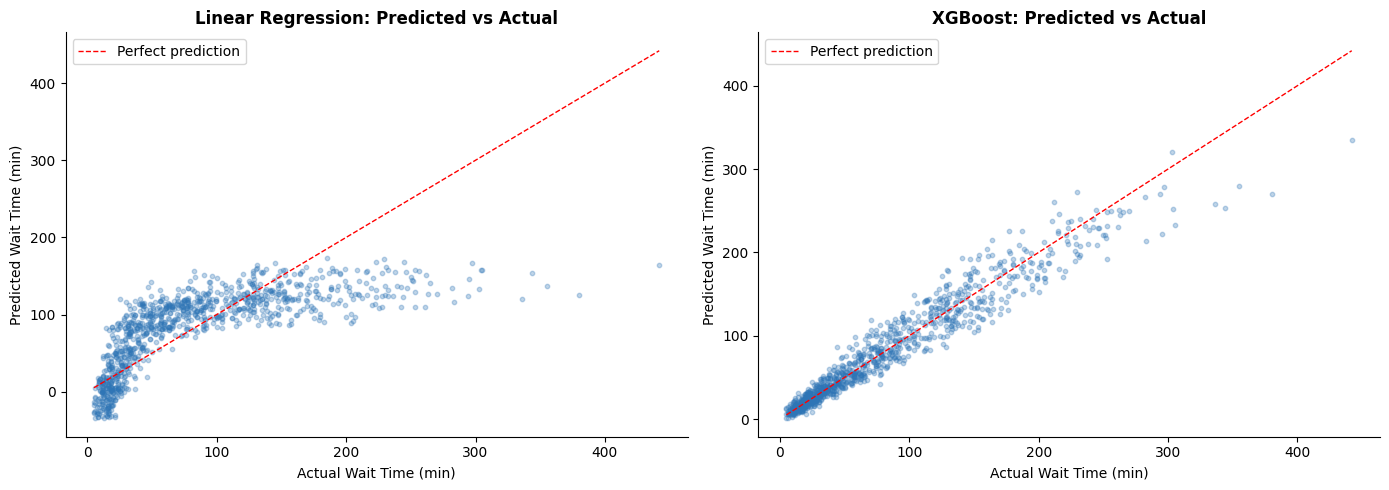

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, name, preds in [
    (axes[0], "Linear Regression", lr_preds),
    (axes[1], "XGBoost",           xgb_preds)
]:
    ax.scatter(y_test, preds, alpha=0.3, s=10, color="#2E75B6")
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()],
            "r--", linewidth=1, label="Perfect prediction")
    ax.set_title(f"{name}: Predicted vs Actual", fontsize=12, fontweight="bold")
    ax.set_xlabel("Actual Wait Time (min)")
    ax.set_ylabel("Predicted Wait Time (min)")
    ax.legend()

plt.tight_layout()
plt.show()

The predicted vs actual plots show that the Linear Regression model has difficulty capturing longer wait times. Many of its predictions are far below the perfect prediction line, which suggests that the model tends to underpredict high wait-time cases.

In contrast, the XGBoost Regressor produces predictions that are much closer to the perfect prediction line. This confirms the evaluation metrics, where XGBoost achieved lower MAE and RMSE and a much higher R² score. Therefore, XGBoost was selected as the stronger model for predicting total ER wait time.

Computing SHAP values...


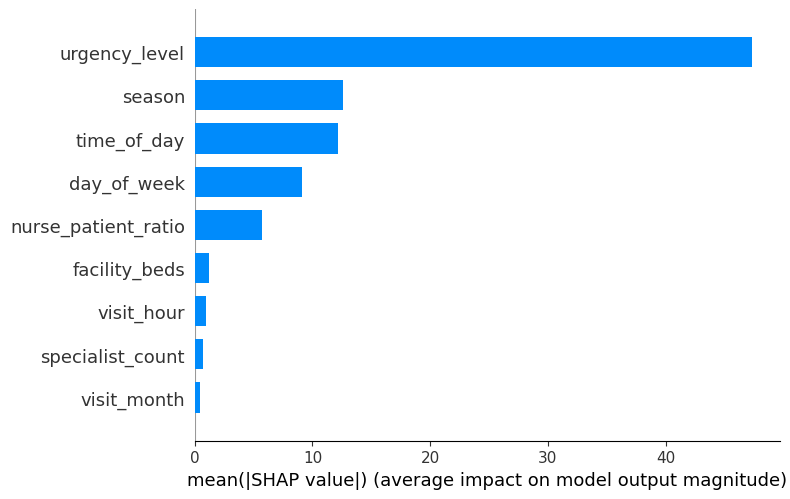

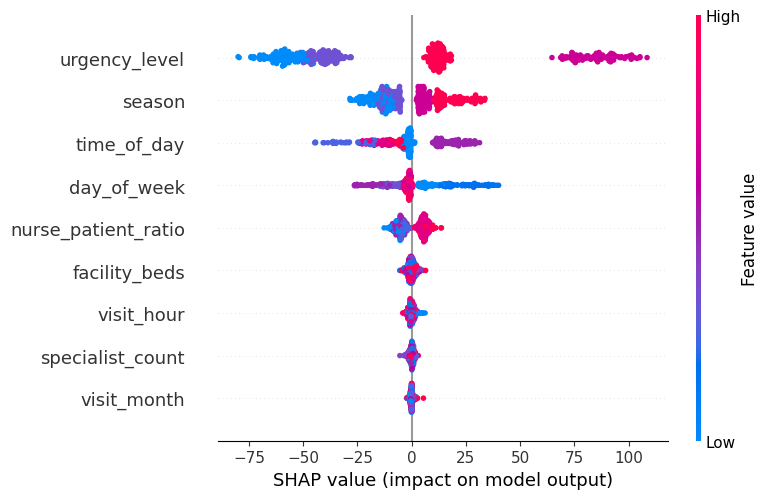


Feature importance by mean absolute SHAP:
            feature  mean_abs_shap
      urgency_level      47.337780
             season      12.589968
        time_of_day      12.128141
        day_of_week       9.138750
nurse_patient_ratio       5.730320
      facility_beds       1.243841
         visit_hour       0.942204
   specialist_count       0.738476
        visit_month       0.473810


In [8]:
# ─────────────────────────────────────────────────────────────
# SHAP: Explain the XGBoost Regressor
# ─────────────────────────────────────────────────────────────
# The XGBoost model gave the best performance, so I use SHAP here to understand which features are driving its predictions.
#
# SHAP helps answer:
#   - Which features matter most?
#   - Do high values of a feature increase or decrease predicted wait time?
#   - Which operational factor should be reviewed first?

print("Computing SHAP values...")

# TreeExplainer is designed for tree-based models like XGBoost.
# It explains how each feature contributes to each prediction.
#
# Note:
# In some versions of XGBoost and SHAP, TreeExplainer may fail because
# the XGBoost base_score is stored in a newer format.
# To avoid this version issue, I use XGBoost's built-in pred_contribs=True,
# which returns SHAP-style feature contribution values directly from the model.

# SHAP can take time on larger datasets, so I use a sample of the test set.
sample = X_test.sample(500, random_state=42)

# Convert the sample into XGBoost's DMatrix format.
# This is the input format expected by XGBoost's native prediction method.
dmatrix_sample = xgb.DMatrix(
    sample,
    feature_names=list(sample.columns)
)

# Calculate SHAP-style contribution values using XGBoost directly.
# pred_contribs=True returns one contribution value for each feature,
# plus one extra final column for the model's base value.
shap_contribs = xgb_model.get_booster().predict(
    dmatrix_sample,
    pred_contribs=True
)

# Calculate SHAP values for the sample.
# Each SHAP value shows how much a feature pushed the prediction
# higher or lower compared with the model's average prediction.
#
# The last column from pred_contribs is the base value, not a feature,
# so I remove it before creating the SHAP plots and importance table.
shap_values = shap_contribs[:, :-1]


# ─────────────────────────────────────────────────────────────
# 1) Global feature importance bar plot
# ─────────────────────────────────────────────────────────────
# This plot ranks features by their average impact on the model.
# It does not show direction; it only shows overall importance.
shap.summary_plot(
    shap_values,
    sample,
    plot_type="bar",
    show=True
)


# ─────────────────────────────────────────────────────────────
# 2) Beeswarm plot
# ─────────────────────────────────────────────────────────────
# This plot shows both importance and direction.
# Points on the right increase predicted wait time.
# Points on the left decrease predicted wait time.
# Red points usually mean high feature values, and blue points mean low values.
shap.summary_plot(
    shap_values,
    sample,
    show=True
)


# ─────────────────────────────────────────────────────────────
# 3) Create a SHAP importance table
# ─────────────────────────────────────────────────────────────
# I calculate the mean absolute SHAP value for each feature.
# A larger value means the feature has a stronger average impact on the model's wait-time predictions.
mean_shap = pd.DataFrame({
    "feature": sample.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False)

print("\nFeature importance by mean absolute SHAP:")
print(mean_shap.to_string(index=False))


# ─────────────────────────────────────────────────────────────
# 4) Simple operational takeaway
# ─────────────────────────────────────────────────────────────
# The top SHAP feature is the factor the model relied on most.
# This does not prove direct causation, but it gives a useful starting point for operational review.
top = mean_shap.iloc[0]["feature"]


## SHAP Analysis — XGBoost ER Wait Time Predictor

**urgency_level** was the dominant feature with a mean absolute SHAP value of 47.3 - nearly four times higher than any other feature. 
In the beeswarm plot, low encoded values (Critical = 0) produce large negative SHAP values, meaning Critical patients are predicted to wait less. High encoded values (Low urgency = 2, Medium = 3) push predictions 
higher. This is clinically expected : Critical patients are seen immediately while Low urgency patients wait the longest.

**season and time_of_day** each contributed around 12–13 SHAP units. 
This tells a hospital operations manager that demand patterns are predictable : certain seasons and times of day consistently drive longer waits. This has a direct operational implication: staffing schedules should be adjusted to match predicted demand, not historical 
averages.

**nurse_patient_ratio** ranked 5th in SHAP importance (5.7) despite having the highest raw correlation with the target (0.688). This apparent contradiction occurs because SHAP measures marginal contribution after other features are accounted for. Once urgency level and time patterns are known, the additional information from 
staffing ratio is less decisive.

**The most actionable insight:** urgency_level is the strongest predictor, but hospitals cannot change how sick patients arrive. 
The most operationally controllable lever is **nurse_patient_ratio** combined with **time_of_day scheduling** — increasing staffing during predicted peak times (specific seasons and hours) would address the second and third most important drivers of wait time. 

In [9]:
shap_er = pd.DataFrame({
    "feature"       : X_test.columns,
    "mean_abs_shap" : np.abs(shap_values).mean(axis=0),
    "model"         : "ER Wait Predictor"
}).sort_values("mean_abs_shap", ascending=False).head(10)

shap_er.to_csv("../data/processed/shap_er_wait.csv", index=False)
print(shap_er)

               feature  mean_abs_shap              model
0        urgency_level      47.337780  ER Wait Predictor
3               season      12.589968  ER Wait Predictor
1          time_of_day      12.128141  ER Wait Predictor
2          day_of_week       9.138750  ER Wait Predictor
5  nurse_patient_ratio       5.730320  ER Wait Predictor
4        facility_beds       1.243841  ER Wait Predictor
7           visit_hour       0.942204  ER Wait Predictor
6     specialist_count       0.738476  ER Wait Predictor
8          visit_month       0.473810  ER Wait Predictor


NameError: name 'shap_readm' is not defined